In [32]:
using LinearAlgebra
using QuantumToolbox
using CairoMakie

In [33]:
const Sub_divisions = 64
const count_iterations = 1024
const iter = 400
const tolerance = 0.998
const step_size = 5
const time_to_iter = 192

initial_state = ComplexF64[1;0]
H_Gate = ComplexF64[1/√2 1/√2; 1/√2 -1/√2]
T_gate = ComplexF64[1 0; 0 exp(im*π/Sub_divisions)]

function apply_gate(state, gate)
    return gate * state
end

function rotate(state, i)
    return T_gate ^ i * state
end

function measure(vec)
    if abs2(vec[1]) > rand()
        vec[1] = 1
        vec[2] = 0
        return 0
        end
    vec[1] = 0
    vec[2] = 1
    return 1
end

function ramsey(state, gate, t)
    prep = apply_gate(state, gate)
    spinning = rotate(prep, t)
    final = apply_gate(spinning, gate)
    return measure(final)
end

function count(n, state, gate, t)
    count = 0
    for i in range(1,n)
        measured = ramsey(state, gate, t)
        if measured < 1
            count += 1
        end
    end
    return count
end

function operate(iter)
    t_range = range(1, iter)
    data = []
    for i in t_range
        push!(data, count(count_iterations, initial_state, H_Gate, i))
    end
    return data
end

function operate_2(time)
    iter = time * 192
    t_range = range(1, iter)
    data = []
    for i in t_range
        push!(data, count(count_iterations, initial_state, H_Gate, i))
    end
    return data
end


function convert_to_prob(lst)
    prob = []
    for i in range(1,length(lst))
        push!(prob, lst[i]/count_iterations)
    end
    return prob
end

convert_to_prob (generic function with 2 methods)

In [34]:
function graph(time)
    operated = operate_2(time)
    probs = convert_to_prob(operated)
    Ts = convert_time(range(1, t * time_to_iter)/1000)
    return [probs, Ts]
end

graph (generic function with 1 method)

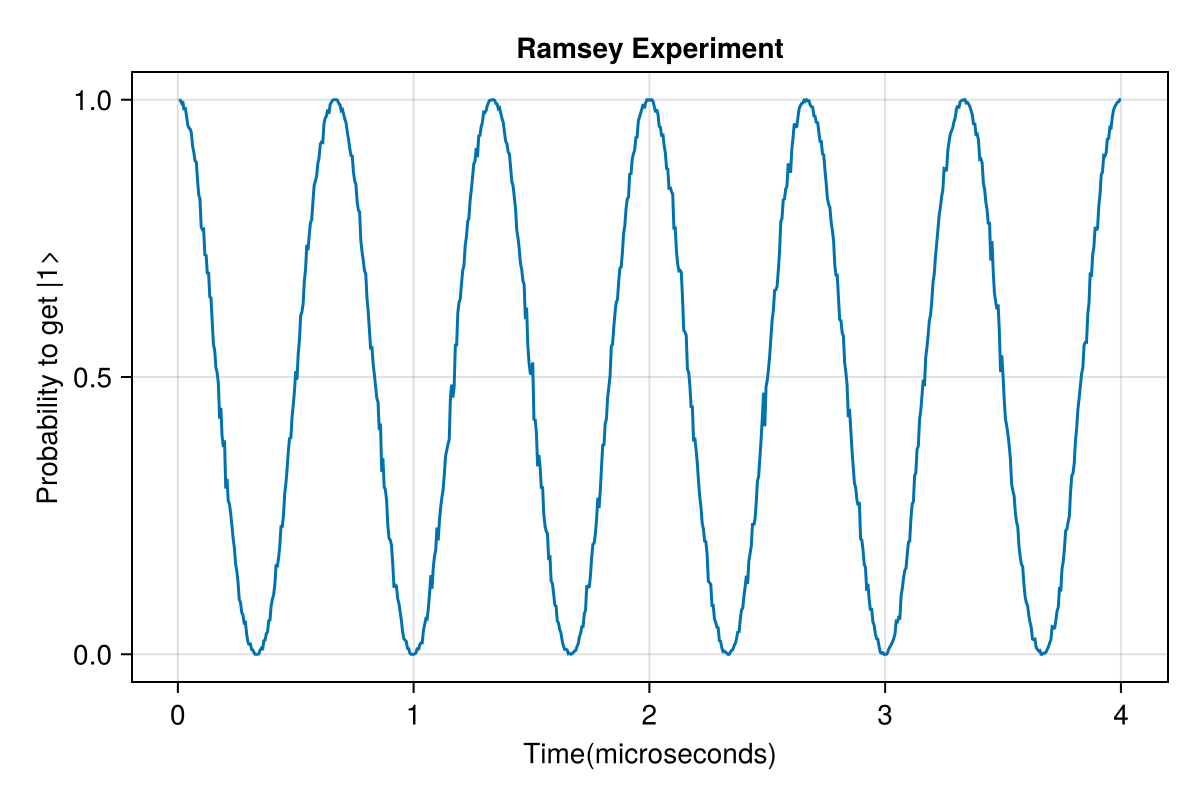

CairoMakie.Screen{IMAGE}


In [ ]:
t = 4 # microseconds
g = graph(t)
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
lines!(ax, g[2], g[1])
display(fig)


In [36]:
ω_01 = 6.063 * 1000 #MHz
ω_pulse = 6.06 * 1000 #MHz
Δf = ω_01 - ω_pulse
precession_time = 1/Δf * 1000
#precession_time is 333 nanoseconds

function convert_time(lst)
    conv = []
    for i in lst
        push!(conv, i * precession_time/64 )
    end
    return conv
end

convert_time (generic function with 1 method)

right now I have to input iters or n into operate but I should be able to input a time into that 

In [37]:
n = 400
probs = convert_to_prob(operate(n))
t_range = range(1, n)
Ts = convert_time(t_range / 1000)

fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
lines!(ax, Ts, probs)
vlines!(ax, precession_time/1000, label = "Time to precess once: $(precession_time/1000)")
axislegend(ax; position = :rb)
display(fig)

println(find_time_periods(n, tolerance)[2])

InterruptException: InterruptException:

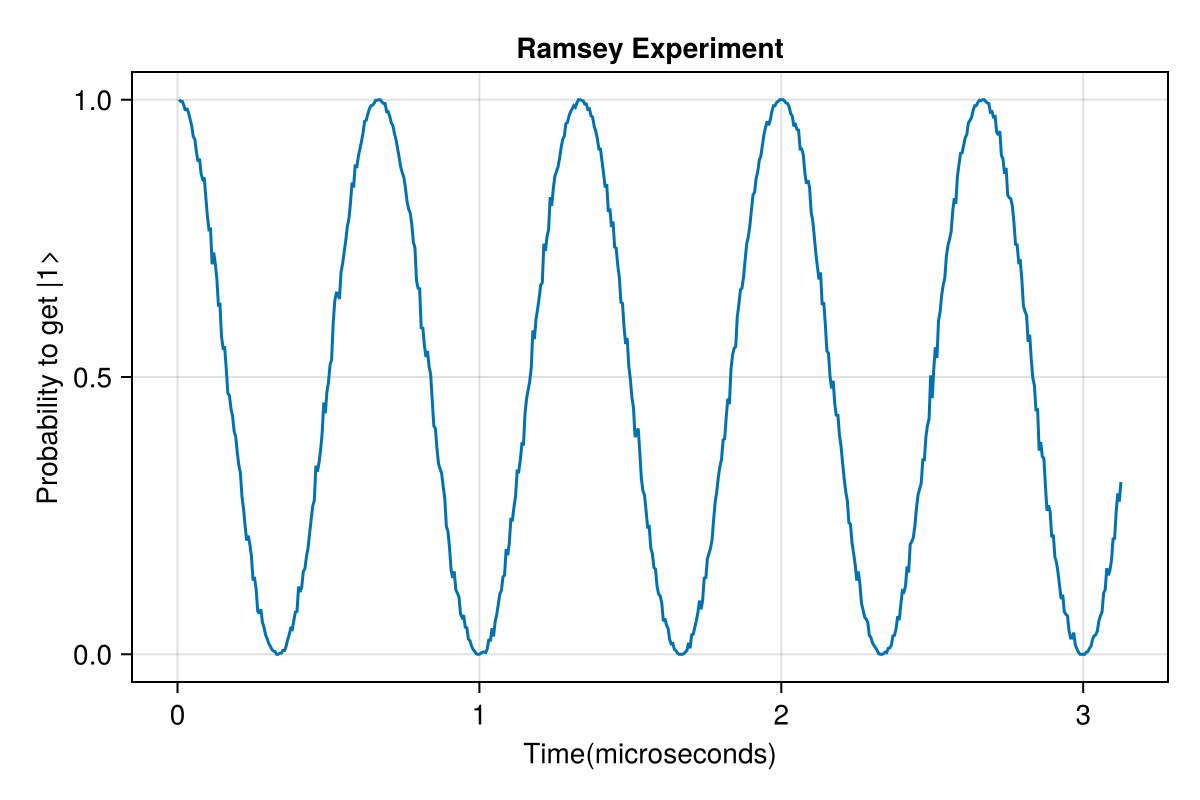

UndefVarError: UndefVarError: `tol` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [38]:
n = 600
probs = convert_to_prob(operate(n))
t_range = range(1, n)

Ts = convert_time(t_range / 1000)
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
lines!(ax, Ts, probs)
display(fig)

println(find_time_periods(n, tol)[2])
println(calc_multi_period(n, tolerance))

In [39]:
function calculate_ramsey_period(lst, tol)
    period = []
    if lst[1]>tol
        push!(period, 1)
    end
    for i in range(1,length(lst); step = 5)
        if i > 5  && i < length(lst) - (5+1)
            if lst[i]>tol
                push!(period, i)
            end
        end
    end
    return [period, (period[length(period)] - period[1])/length(period)]
end


function calc_multi_period(time, tol)
    periods = []
    for i in range(1,10)
        push!(periods, calculate_ramsey_period(convert_to_prob(operate(time)), tol)[2])
    end
    return [periods, maximum(periods), sum(periods)/length(periods)]
end

function convert_to_freq(time, tol)
    return 1/(calc_multi_period(time, tol)[3])
end

function find_time_periods(iters, tol)
    time_period = []
    for i in range(1, 10)
        probs = convert_to_prob(operate(iters))
        push!(time_period, convert_time(calculate_ramsey_period(probs, tol)[1])/1000)
    end
    time_lst_shrunk = []
    for i in range(1,10)
        for j in range(1,length(time_period[i]))
            if time_period[i][j] ∉ time_lst_shrunk
                push!(time_lst_shrunk, time_period[i][j])
            end
        end
    end
    sort!(time_lst_shrunk)
    return [time_period, time_lst_shrunk]
end

function calc_time_period(iters, tol)
    times =  find_time_periods(iters, tol)[2]
    return [times, (times[end] - times[1])/length(times), sum(times)/length(times)]
end

function convert_time_to_freq(iters, tol)
    return 1/calc_time_period(iters, tol)[2]
end

convert_time_to_freq (generic function with 1 method)

In [ ]:
iter_2 = 6000
t_range = range(1, iter_2)
Ts = convert_time(t_range / 1000)
Δ = convert_to_freq(iter_2, tolerance) * 1000


In [ ]:
iter_2 = 6000
t_range = range(1, iter_2)
Ts = convert_time(t_range / 1000)

A = 0.5
C = 0.5
T1 = 15 * 1000 #Microseconds(1000x nanoseconds)
Tϕ = 10^3 * 1000 #Microseconds(1000x nanoseconds)
T2x = (1/2T1 + 1/Tϕ)^-1/1000

function P(t, A, C)
    return A * exp(-t/T2x) * cos(2π* Δ * t) + C
end
decaying = []
border = []
for i in Ts
    push!(decaying, P(i, A, C))
    push!(border, A * exp(-i/T2x) + C)
end


In [ ]:
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
lines!(ax, Ts, decaying)
lines!(ax, Ts, border)
hlines!(ax, 1-1/ℯ, linewidth = 3, color = :red, linestyle = :dash)
CairoMakie.ylims!(ax, (0.0, 1.0))
display(fig)

In [ ]:
save("Ramsey_expirement_w_decay.png", fig)